# 2 · Mixed races with `MixedRace`

**Use `MixedRace` when individuals of different categories race each other, one ergometer each**, e.g. junior women, senior men and masters over 2000 m. Each entry is one athlete. Athletes can carry a team label; teams are then ranked by the mean score of their athletes.

| Your race | Class |
|---|---|
| team takes turns on **one** erg | `RelayRace` → notebook 1 |
| individuals of different categories, one erg each | **`MixedRace`** (this notebook) |
| boats (1x … 8+) with mixed crews on the water | `CrewRace` → notebook 3 |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))   # use the repo copy of ergrace
%matplotlib inline
import numpy as np
import pandas as pd
pd.set_option("display.precision", 4)

from ergrace import MixedRace, References

## 2000 m with a staggered start

Lanes can be given as a category, `(name, category)` or `(name, category, team)`.


   MIXED RACE 2000 m: STAGGERED START (expected level 70% of reference power)   
 Start # Entry  Lane Category Expected Time Start Offset Gap to Prev (s)
       1 Karin     3    Mas W        7:43.6      +0:00.0             0.0
       2  Anna     1    Jun W        7:30.7      +0:12.8            12.8
       3 Sofia     5    Sen W        7:09.2      +0:34.4            21.5
       4 Johan     4    Mas M        6:47.1      +0:56.4            22.1
       5  Leon     6    Jun M        6:35.8      +1:07.8            11.4
       6  Erik     2    Sen M        6:17.0      +1:26.6            18.8



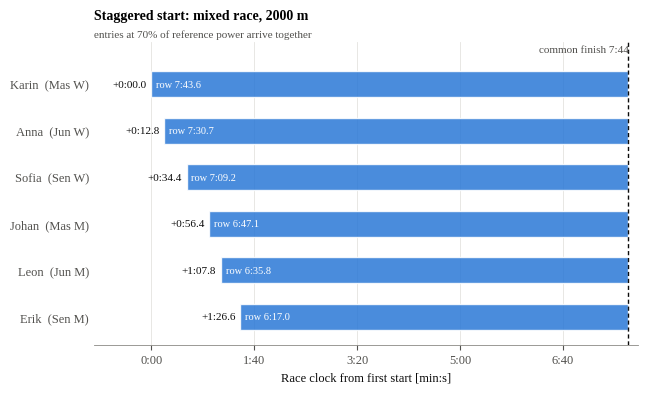

In [2]:
race = MixedRace(distance=2000, level=0.7, lanes={
    1: ("Anna",  "Junior W", "Mölndal"),
    2: ("Erik",  "Senior M", "Mölndal"),
    3: ("Karin", "Master W", "Chalmers"),
    4: ("Johan", "Master M", "Chalmers"),
    5: ("Sofia", "Senior W", "Mölndal"),
    6: ("Leon",  "Junior M", "Chalmers"),
})
race.print_handicaps()
race.plot_handicaps();

Results can be entered by athlete name or lane:

In [3]:
race.record({"Anna": "7:48.0", "Erik": "6:52.5", 3: "8:06.2",
             4: "7:05.8", "Sofia": "7:39.9", "Leon": "7:21.4"})
race.print_results()
race.print_team_results()


                    MIXED RACE 2000 m: RESULTS (Score = fraction of reference power)                    
 Rank Entry  Lane     Team Category   Time Split /500 m Speed Score  Score  Line Order Vs Handicap (s)
    1  Anna     1  Mölndal    Jun W 7:48.0       1:57.0      0.8551 0.6253           1         +0:17.3
    2 Johan     4 Chalmers    Mas M 7:05.8       1:46.5      0.8490 0.6119           2         +0:18.7
    3 Karin     3 Chalmers    Mas W 8:06.2       2:01.5      0.8466 0.6067           3         +0:22.6
    4 Sofia     5  Mölndal    Sen W 7:39.9       1:55.0      0.8287 0.5690           4         +0:30.7
    5  Erik     2  Mölndal    Sen M 6:52.5       1:43.1      0.8114 0.5342           5         +0:35.5
    6  Leon     6 Chalmers    Jun M 7:21.4       1:50.3      0.7961 0.5046           6         +0:45.6


                  MIXED RACE 2000 m: TEAMS (mean power score)                   
 Rank     Team  Athletes  Score   Best  Worst
    1  Mölndal         3 0.5762 0.6253 0.534

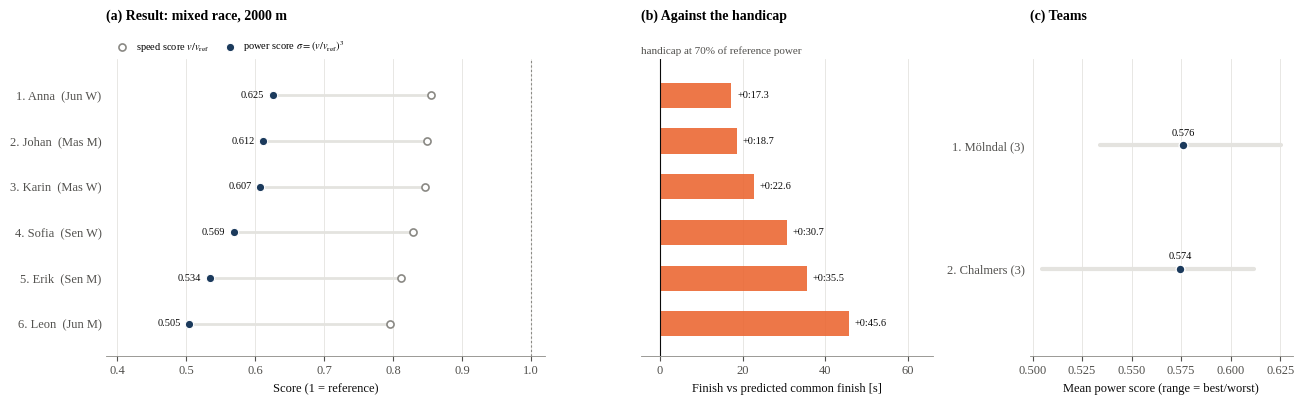

In [4]:
race.plot_results();

Panel (b) shows each athlete's finish relative to the predicted common finish: negative is earlier than the handicap predicted. Panel (c) ranks the teams by mean σ; the bar spans their best and worst athlete.

## A 20-minute race with your own references (fixed time)

Here the club defines its own 2000 m benchmarks. Results are distances; the handicap is a target distance per athlete.


   MIXED RACE 20:00: TARGET DISTANCES (expected level 80% of reference power)   
 Entry Category Target Distance (m) Credit (m)
Lane 3    Mas W                4690       1022
Lane 1    Jun W                4791        921
Lane 4    Mas M                5369        344
Lane 2    Sen M                5713          0



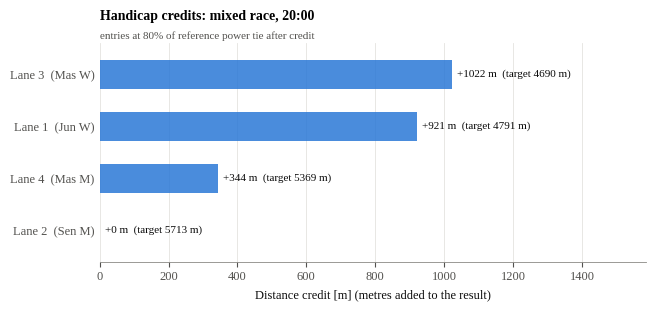

In [5]:
club = References(2000, {"Senior M": "6:30", "Senior W": "7:25",
                         "Junior M": "6:45", "Junior W": "7:45",
                         "Master M": "6:55", "Master W": "7:55"})
race20 = MixedRace(time="20:00", references=club, level=0.8,
                   lanes={1: "Junior W", 2: "Senior M", 3: "Master W", 4: "Master M"})
race20.print_handicaps()
race20.plot_handicaps();


              MIXED RACE 20:00: RESULTS (Score = fraction of reference power)              
 Rank  Entry  Lane Category Distance (m) Split /500 m Speed Score  Score Vs Handicap (m)
    1 Lane 3     3    Mas W         4390       2:16.7      0.8689 0.6559            -300
    2 Lane 1     1    Jun W         4410       2:16.1      0.8544 0.6238            -381
    3 Lane 4     4    Mas M         4905       2:02.3      0.8482 0.6101            -464
    4 Lane 2     2    Sen M         5160       1:56.3      0.8385 0.5895            -553



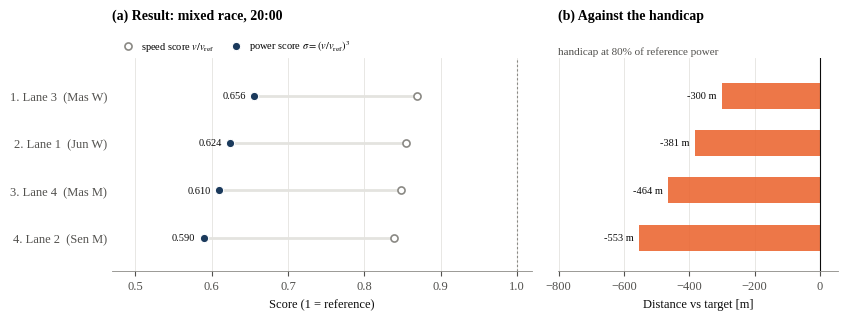

In [6]:
race20.record({1: 4410, 2: 5160, 3: 4390, 4: 4905})
race20.print_results()
race20.plot_results();

---
## Limit cases

### 1 · Everyone in the same category → no handicap
The ranking is then simply the finishing order, and σ still tells you how close each athlete came to the reference.

In [7]:
same = MixedRace(distance=2000, lanes={1: "Senior W", 2: "Senior W", 3: "Senior W"})
same.print_handicaps()
same.record({1: "7:10", 2: "7:30", 3: "7:05"}).results()[["Rank", "Entry", "Time", "Score"]]


  MIXED RACE 2000 m: STAGGERED START (expected level 100% of reference power)   
 Start #  Entry  Lane Category Expected Time Start Offset Gap to Prev (s)
       1 Lane 1     1    Sen W        6:21.1      +0:00.0             0.0
       2 Lane 2     2    Sen W        6:21.1      +0:00.0             0.0
       3 Lane 3     3    Sen W        6:21.1      +0:00.0             0.0



,Rank,Entry,Time,Score
0,1,Lane 3,7:05.0,0.7210
1,2,Lane 1,7:10.0,0.6962
2,3,Lane 2,7:30.0,0.6074


### 2 · Rowing exactly the reference time gives σ = 1; the score is a power ratio
Rowing 10 % slower than the reference means sustaining only 0.9³ ≈ 73 % of the reference power.

In [8]:
ref = MixedRace(distance=2000, lanes={1: "Senior M", 2: "Senior M"})
ref.record({1: "5:34.7", 2: 334.7 / 0.9})
ref.results()[["Entry", "Time", "Speed Score", "Score"]]

,Entry,Time,Speed Score,Score
0,Lane 1,5:34.7,1.0,1.000
1,Lane 2,6:11.9,0.9,0.729


### 3 · Handicaps depend only on category *ratios*
Scaling all references by the same factor leaves the ranking unchanged and only rescales the scores.

In [9]:
fast = References(2000, {"Senior M": 400, "Junior W": 480})
slow = References(2000, {"Senior M": 440, "Junior W": 528})          # all 10 % slower
res = {1: "7:00", 2: "8:10"}
for refs in (fast, slow):
    r = MixedRace(distance=2000, references=refs, lanes={1: "Senior M", 2: "Junior W"})
    print(r.record(res).results()[["Rank", "Entry", "Score"]].to_string(index=False), "\n")

 Rank  Entry  Score
    1 Lane 2 0.9400
    2 Lane 1 0.8638 

 Rank  Entry  Score
    1 Lane 2 1.2512
    2 Lane 1 1.1498 



### 4 · Long races and fatigue
References are 2000 m times. By default they are applied at any distance assuming constant power, which makes predicted times optimistic for long races. `fatigue=5` slows the reference split by 5 s/500 m per doubling of distance (Paul's law). In a distance race everyone rows the same distance, so the correction adds the same time to every athlete: **the start offsets are unchanged**, only the predicted times and the scores move. Fatigue matters for the handicap when athletes row *different* distances, e.g. relay teams of different sizes (notebook 1).

In [10]:
for f in (None, 5):
    r = MixedRace(distance=6000, fatigue=f, level=0.7,
                  lanes={1: "Senior M", 2: "Junior W", 3: "Master W"})
    print(f"fatigue={f}")
    print(r.handicaps()[["Entry", "Category", "Expected Time", "Start Offset"]].to_string(index=False), "\n")

fatigue=None
 Entry Category Expected Time Start Offset
Lane 3    Mas W       23:10.7      +0:00.0
Lane 2    Jun W       22:32.2      +0:38.5
Lane 1    Sen M       18:50.9      +4:19.8 

fatigue=5
 Entry Category Expected Time Start Offset
Lane 3    Mas W       24:57.8      +0:00.0
Lane 2    Jun W       24:19.3      +0:38.5
Lane 1    Sen M       20:38.0      +4:19.8 



### 5 · Category labels
Labels are forgiving: `"Senior M"`, `"senior men"`, `"M"`, `"Junior F"`, `"women junior"`, `"Masters W"` all work. Unknown categories raise a clear error.

In [11]:
from ergrace.references import parse_category
for lab in ["Senior M", "M", "junior f", "women junior", "Masters W"]:
    print(f"{lab!r:16} -> {parse_category(lab)}")
try:
    MixedRace(distance=2000, lanes={1: "Veteran X"})
except ValueError as err:
    print("error:", err)

'Senior M'       -> ('senior', 'M')
'M'              -> ('senior', 'M')
'junior f'       -> ('junior', 'W')
'women junior'   -> ('junior', 'W')
'Masters W'      -> ('master', 'W')
error: Unknown token 'x' in category 'Veteran X'; use e.g. 'Senior M', 'Junior W', 'Master F'
